# Predict 30-day readmission

This ML project predicts the re-admission of a sample of patients after a 30-day.

We use the available UCI Diabetes Readmission Dataset encoded from Kaggle

In [1]:
#import the necessary modules 
import numpy as np
import pandas as pd
#import sklearn as sk
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import sqlite3
import seaborn as sns
%matplotlib inline

In [2]:
#download the dataset from Kaggle

import kagglehub

# Download latest version
path = kagglehub.dataset_download("chawthinn21/uci-diabetes-readmission-dataset-encoded")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\gemma\.cache\kagglehub\datasets\chawthinn21\uci-diabetes-readmission-dataset-encoded\versions\1


In [3]:
# Load dataset
from pathlib import Path
df = pd.read_csv(Path(path) / "diabetes_cleaned_onehot.csv")
#df = pd.read_csv(path + "\diabetes_cleaned_onehot.csv")  # adjust filename if needed

# Create SQLite DB
conn = sqlite3.connect("hospital.db")

# Write to SQL
df.to_sql("patients", conn, if_exists="replace", index=False)

74744

In [4]:
#check columns
pd.read_sql("PRAGMA table_info(patients);", conn)

#preview data
pd.read_sql("SELECT * FROM patients LIMIT 5;", conn)

,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,glimepiride-pioglitazone_Steady,metformin-rosiglitazone_No,metformin-rosiglitazone_Steady,metformin-pioglitazone_No,metformin-pioglitazone_Steady,change_Ch,change_No,diabetesMed_No,diabetesMed_Yes,readmitted_label
0,1,1,7,2,11,5,13,2,0,1,...,0,1,0,1,0,0,1,0,1,0
1,1,1,7,2,44,1,16,0,0,0,...,0,1,0,1,0,1,0,0,1,0
2,1,1,7,1,51,0,8,0,0,0,...,0,1,0,1,0,1,0,0,1,0
3,2,1,2,3,31,6,16,0,0,0,...,0,1,0,1,0,0,1,0,1,1
4,3,1,2,4,70,1,21,0,0,0,...,0,1,0,1,0,1,0,0,1,0


In [5]:
#clean with SQL
#NOTE: since this dataset is already cleaned, this step is not needed.

#conn.execute("DROP TABLE IF EXISTS patients_clean;")

#conn.execute("""
#CREATE TABLE patients_clean AS
#SELECT
#    patient_nbr,
#    age,
#    time_in_hospital,
#    num_lab_procedures,
#    num_medications,
#    CASE WHEN readmitted = '<30' THEN 1 ELSE 0 END AS readmitted,
#    (number_inpatient + number_emergency + number_outpatient) AS total_visits
#FROM patients
#WHERE gender != 'Unknown/Invalid';
#""")

#conn.commit()

In [6]:
# Load for ML
df_clean = pd.read_sql("SELECT * FROM patients;", conn)
df_clean

,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,glimepiride-pioglitazone_Steady,metformin-rosiglitazone_No,metformin-rosiglitazone_Steady,metformin-pioglitazone_No,metformin-pioglitazone_Steady,change_Ch,change_No,diabetesMed_No,diabetesMed_Yes,readmitted_label
0,1,1,7,2,11,5,13,2,0,1,...,0,1,0,1,0,0,1,0,1,0
1,1,1,7,2,44,1,16,0,0,0,...,0,1,0,1,0,1,0,0,1,0
2,1,1,7,1,51,0,8,0,0,0,...,0,1,0,1,0,1,0,0,1,0
3,2,1,2,3,31,6,16,0,0,0,...,0,1,0,1,0,0,1,0,1,1
4,3,1,2,4,70,1,21,0,0,0,...,0,1,0,1,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74739,1,1,7,5,21,1,16,0,0,1,...,0,1,0,1,0,0,1,0,1,0
74740,1,1,7,6,45,1,25,3,1,2,...,0,1,0,1,0,1,0,0,1,1
74741,1,3,7,3,51,0,16,0,0,0,...,0,1,0,1,0,1,0,0,1,1
74742,1,1,7,1,53,0,9,1,0,0,...,0,1,0,1,0,1,0,0,1,0


In [7]:
#Understand the columns and information we have:
print(df_clean.shape)
print(df_clean.dtypes.value_counts()) #the data is already cleaned so they are all integers
df_clean.head(2)
print(df_clean['readmitted_label'].value_counts()) #0,1,2, either not readmitted, in <30 or >30
#Change it to binary, so 1,2 become 1
df_clean['readmitted_binary'] = (df_clean['readmitted_label'] != 0).astype(int)
print(df_clean['readmitted_binary'].value_counts())
df_clean= df_clean.drop(columns=['readmitted_label'])

(74744, 108)
int64    108
Name: count, dtype: int64
readmitted_label
0    39998
1    26650
2     8096
Name: count, dtype: int64
readmitted_binary
0    39998
1    34746
Name: count, dtype: int64


In [8]:
#when deciding which columns to drop, check for near-zero variance columns (not much info)

selector = VarianceThreshold(threshold=0.01)
selector.fit(df_clean.drop(columns=['readmitted_binary']))

low_var_cols = df_clean.drop(columns=['readmitted_binary']).columns[~selector.get_support()].tolist()
print(f"Low variance columns to drop ({len(low_var_cols)}): {low_var_cols}")

#drop the columns with low variance
df_model = df_clean.drop(columns=low_var_cols)
print(f"Remaining columns: {df_model.shape[1]}") #new dataset with less columns

Low variance columns to drop (51): ['race_Asian', 'gender_Unknown/Invalid', 'metformin_Down', 'repaglinide_Down', 'repaglinide_Up', 'nateglinide_Down', 'nateglinide_No', 'nateglinide_Steady', 'nateglinide_Up', 'chlorpropamide_No', 'chlorpropamide_Steady', 'chlorpropamide_Up', 'glimepiride_Down', 'glimepiride_Up', 'acetohexamide_No', 'acetohexamide_Steady', 'glipizide_Down', 'glipizide_Up', 'glyburide_Down', 'glyburide_Up', 'tolbutamide_No', 'tolbutamide_Steady', 'pioglitazone_Down', 'pioglitazone_Up', 'rosiglitazone_Down', 'rosiglitazone_Up', 'acarbose_No', 'acarbose_Steady', 'acarbose_Up', 'miglitol_Down', 'miglitol_No', 'miglitol_Steady', 'miglitol_Up', 'troglitazone_No', 'troglitazone_Steady', 'tolazamide_No', 'tolazamide_Steady', 'examide_No', 'citoglipton_No', 'glyburide-metformin_Down', 'glyburide-metformin_No', 'glyburide-metformin_Steady', 'glyburide-metformin_Up', 'glipizide-metformin_No', 'glipizide-metformin_Steady', 'glimepiride-pioglitazone_No', 'glimepiride-pioglitazone_S

In [9]:
#drop columns highly correlated with each other
X_temp = df_model.drop(columns=['readmitted_binary'])
corr_matrix = X_temp.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_cols = [col for col in upper.columns if any(upper[col] > 0.95)]
print(f"High-correlation columns to drop ({len(high_corr_cols)}): {high_corr_cols}")

df_model = df_model.drop(columns=high_corr_cols)
print(f"Final column count: {df_model.shape[1]}")

High-correlation columns to drop (6): ['gender_Male', 'repaglinide_Steady', 'pioglitazone_Steady', 'rosiglitazone_Steady', 'change_No', 'diabetesMed_Yes']
Final column count: 51


In [10]:
#train/test split


X=df_model.drop(columns=['readmitted_binary'])
y=df_model['readmitted_binary']

# 80% train, 20% test 
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train positive rate: {y_train.mean():.3f}")
print(f"Test positive rate:  {y_test.mean():.3f}")

Train: (59795, 50), Test: (14949, 50)
Train positive rate: 0.465
Test positive rate:  0.465


In [11]:
#train a model, using random forest


pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        class_weight='balanced',   # important: handles class imbalance
        random_state=42,
        n_jobs=-1
    ))
])

pipe.fit(X_train, y_train)
print("Training complete.")

Training complete.


In [12]:
#Evaluate on the held out test set
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
)
import matplotlib.pyplot as plt

y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Not Readmitted', 'Readmitted']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

                precision    recall  f1-score   support

Not Readmitted       0.65      0.70      0.67      8000
    Readmitted       0.62      0.57      0.59      6949

      accuracy                           0.64     14949
     macro avg       0.63      0.63      0.63     14949
  weighted avg       0.64      0.64      0.64     14949

ROC-AUC: 0.6834


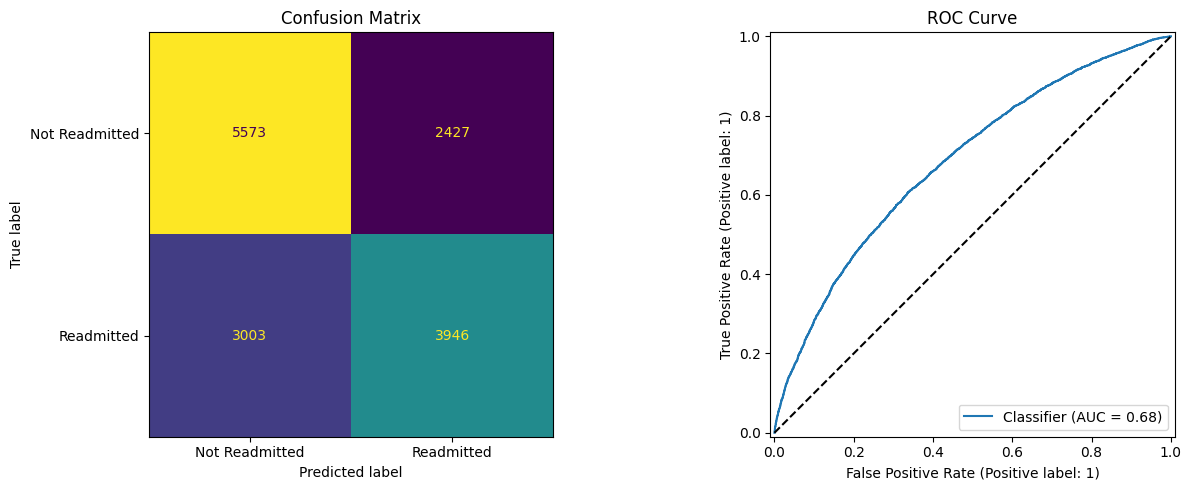

In [13]:
# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Not Readmitted', 'Readmitted'],
    ax=axes[0], colorbar=False
)
axes[0].set_title("Confusion Matrix")

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title("ROC Curve")
axes[1].plot([0,1],[0,1],'k--')

plt.tight_layout()
plt.show()

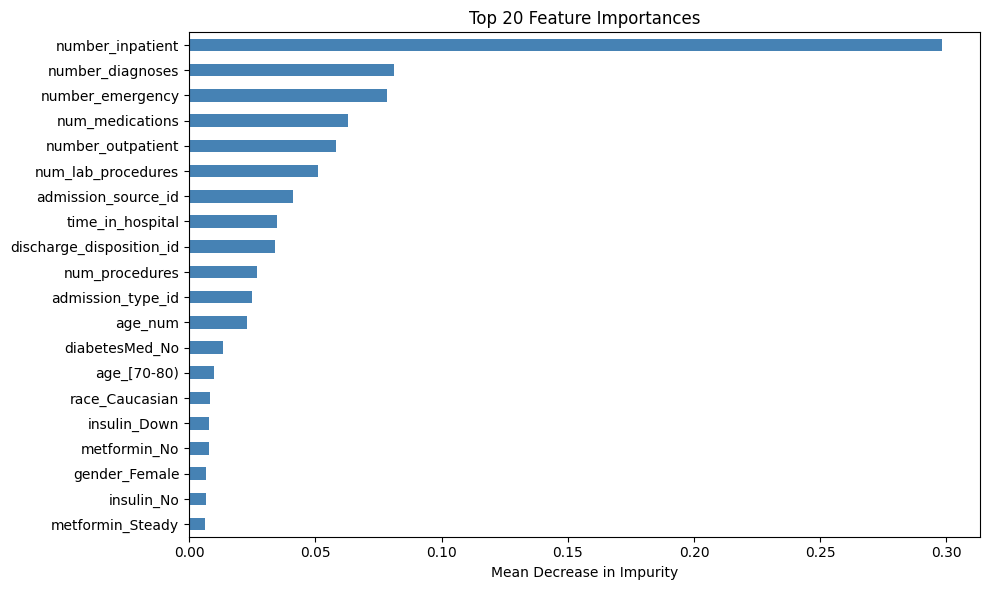

In [14]:
rf_model = pipe.named_steps['clf']
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top20 = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
top20.sort_values().plot(kind='barh', color='steelblue')
plt.title("Top 20 Feature Importances")
plt.xlabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.show()

In [15]:


pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

pipe_lr.fit(X_train, y_train)
y_proba_lr = pipe_lr.predict_proba(X_test)[:, 1]

print(f"Random Forest ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(f"Logistic Regression ROC-AUC: {roc_auc_score(y_test, y_proba_lr):.4f}")

Random Forest ROC-AUC: 0.6834
Logistic Regression ROC-AUC: 0.6706
